<a href="https://colab.research.google.com/github/aazyat-dev/init_lulc/blob/main/Lesson_1_First_Geospatial_Script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries installed and imported successfully!

--- Vector GeoDataFrame ---
  location_name                geometry
0  Paris Center  POINT (2.3522 48.8566)
1  Eiffel Tower  POINT (2.2945 48.8584)


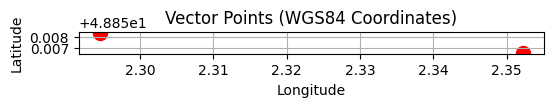

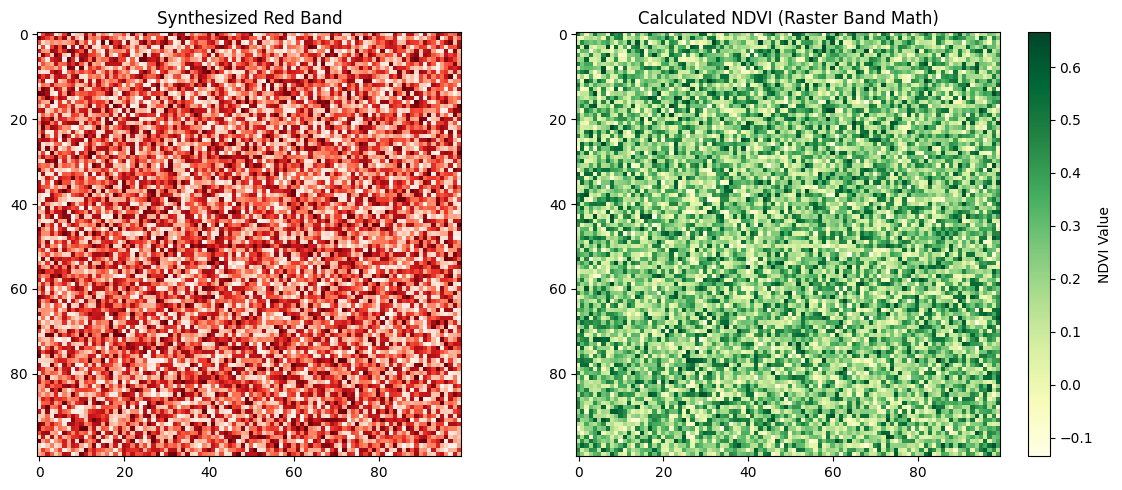

In [1]:
# ==========================================
# 1. SETUP & INSTALLATION
# ==========================================
!pip install -q geopandas rasterio matplotlib shapely

import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon

print("Libraries installed and imported successfully!")

# ==========================================
# 2. VECTOR DATA (GeoPandas)
# ==========================================
# Concept: Vectors store coordinates (Points, Lines, Polygons) with attribute tables.

# Create two sample geographic points (Lon, Lat)
p1 = Point(2.3522, 48.8566)  # Paris Center
p2 = Point(2.2945, 48.8584)  # Eiffel Tower

# Build a GeoDataFrame (Spatial DataFrame)
gdf = gpd.GeoDataFrame(
    {'location_name': ['Paris Center', 'Eiffel Tower']},
    geometry=[p1, p2],
    crs="EPSG:4326"  # Standard WGS84 Geographic Coordinate System
)

print("\n--- Vector GeoDataFrame ---")
print(gdf)

# Plotting Vectors
fig, ax = plt.subplots(figsize=(6, 6))
gdf.plot(ax=ax, color='red', markersize=100)
plt.title("Vector Points (WGS84 Coordinates)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

# ==========================================
# 3. RASTER DATA & BAND MATH (Rasterio & NumPy)
# ==========================================
# Concept: Rasters are 2D/3D grids (arrays) of pixel values, like satellite imagery.

# Generate a synthetic 100x100 2-band satellite image (Red and NIR bands)
height, width = 100, 100

# Red Band (Band 1): Higher values simulate bare soil/urban area
red_band = np.random.randint(50, 200, size=(height, width)).astype('float32')

# Near-Infrared / NIR Band (Band 2): High values simulate healthy vegetation
nir_band = np.random.randint(150, 255, size=(height, width)).astype('float32')

# Calculate NDVI (Normalized Difference Vegetation Index) locally using NumPy
# Formula: NDVI = (NIR - RED) / (NIR + RED)
ndvi = (nir_band - red_band) / (nir_band + red_band)

# Plotting Raster Data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Pseudo True Color / Band Visual
ax1.imshow(red_band, cmap='Reds')
ax1.set_title("Synthesized Red Band")

# Plot Calculated NDVI
ndvi_plot = ax2.imshow(ndvi, cmap='YlGn')
ax2.set_title("Calculated NDVI (Raster Band Math)")
plt.colorbar(ndvi_plot, ax=ax2, label="NDVI Value")

plt.tight_layout()
plt.show()